Dataset loaded successfully!

First 5 rows:


,Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost
0,1,"London, UK",5/1/2023,5/8/2023,7.0,John Smith,35.0,Male,American,Hotel,1200,Flight,600
1,2,"Phuket, Thailand",6/15/2023,6/20/2023,5.0,Jane Doe,28.0,Female,Canadian,Resort,800,Flight,500
2,3,"Bali, Indonesia",7/1/2023,7/8/2023,7.0,David Lee,45.0,Male,Korean,Villa,1000,Flight,700
3,4,"New York, USA",8/15/2023,8/29/2023,14.0,Sarah Johnson,29.0,Female,British,Hotel,2000,Flight,1000
4,5,"Tokyo, Japan",9/10/2023,9/17/2023,7.0,Kim Nguyen,26.0,Female,Vietnamese,Airbnb,700,Train,200



Dataset Shape:
(139, 13)

Column Names:
['Trip ID', 'Destination', 'Start date', 'End date', 'Duration (days)', 'Traveler name', 'Traveler age', 'Traveler gender', 'Traveler nationality', 'Accommodation type', 'Accommodation cost', 'Transportation type', 'Transportation cost']

Data Types:
Trip ID                   int64
Destination                 str
Start date                  str
End date                    str
Duration (days)         float64
Traveler name               str
Traveler age            float64
Traveler gender             str
Traveler nationality        str
Accommodation type          str
Accommodation cost          str
Transportation type         str
Transportation cost         str
dtype: object

Descriptive Statistics:


,Trip ID,Duration (days),Traveler age
count,139.000000,137.000000,137.000000
mean,70.000000,7.605839,33.175182
std,40.269923,1.601276,7.145441
min,1.000000,5.000000,20.000000
25%,35.500000,7.000000,28.000000
50%,70.000000,7.000000,31.000000
75%,104.500000,8.000000,38.000000
max,139.000000,14.000000,60.000000



Missing Values:
Trip ID                 0
Destination             2
Start date              2
End date                2
Duration (days)         2
Traveler name           2
Traveler age            2
Traveler gender         2
Traveler nationality    2
Accommodation type      2
Accommodation cost      2
Transportation type     3
Transportation cost     3
dtype: int64

Duplicate Rows:
0

Missing Values After Cleaning:
Trip ID                 0
Destination             0
Start date              2
End date                2
Duration (days)         0
Traveler name           2
Traveler age            0
Traveler gender         0
Traveler nationality    0
Accommodation type      0
Accommodation cost      0
Transportation type     0
Transportation cost     0
dtype: int64

Total Trip Cost calculated successfully.


,Trip ID,Destination,Total Trip Cost
133,134,"New York City, USA",10500.0
138,139,"Auckland, New Zealand",9500.0
131,132,"Sydney, Australia",9000.0
129,130,"Tokyo, Japan",8500.0
137,138,"Barcelona, Spain",8500.0
135,136,"Vancouver, Canada",8000.0
128,129,"Paris, France",7500.0
132,133,"Rome, Italy",5500.0
130,131,"Cape Town, South Africa",5000.0
134,135,"Rio de Janeiro, Brazil",4500.0



Numeric Columns:
['Trip ID', 'Duration (days)', 'Traveler age', 'Accommodation cost', 'Transportation cost', 'Total Trip Cost']

Categorical Columns:
['Destination', 'Start date', 'End date', 'Traveler name', 'Traveler gender', 'Traveler nationality', 'Accommodation type', 'Transportation type']


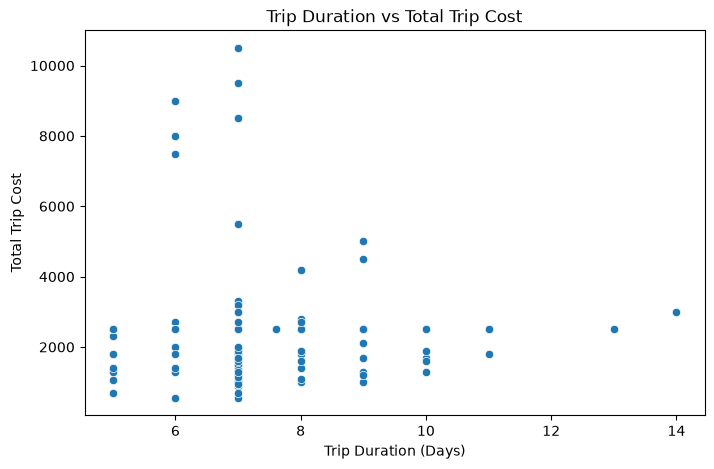

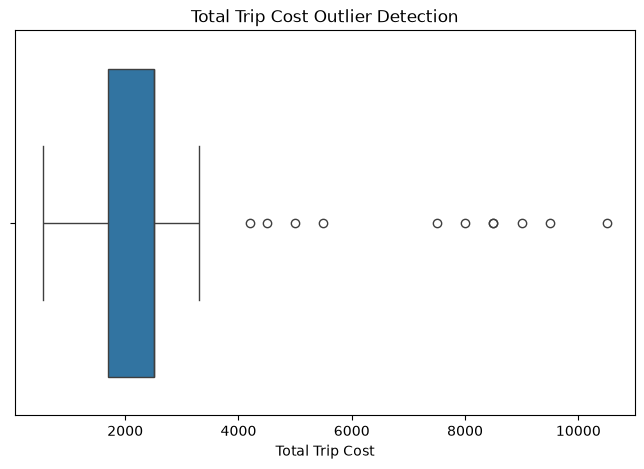

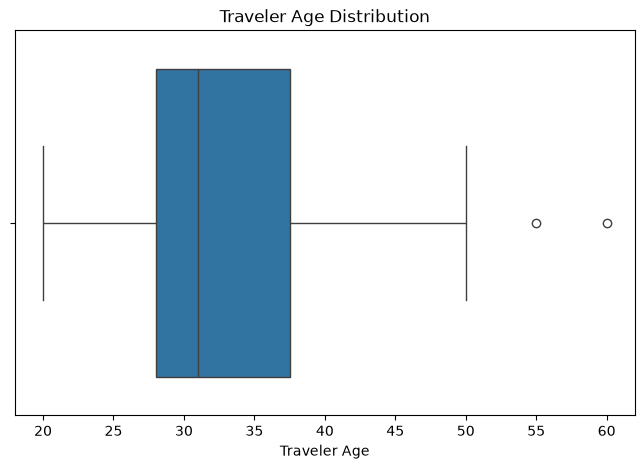


Correlation Matrix:


,Duration (days),Traveler age,Accommodation cost,Transportation cost,Total Trip Cost
Duration (days),1.000000,-0.120520,-0.076255,0.063430,-0.037371
Traveler age,-0.120520,1.000000,0.005905,-0.028842,-0.004273
Accommodation cost,-0.076255,0.005905,1.000000,0.821681,0.985322
Transportation cost,0.063430,-0.028842,0.821681,1.000000,0.906914
Total Trip Cost,-0.037371,-0.004273,0.985322,0.906914,1.000000


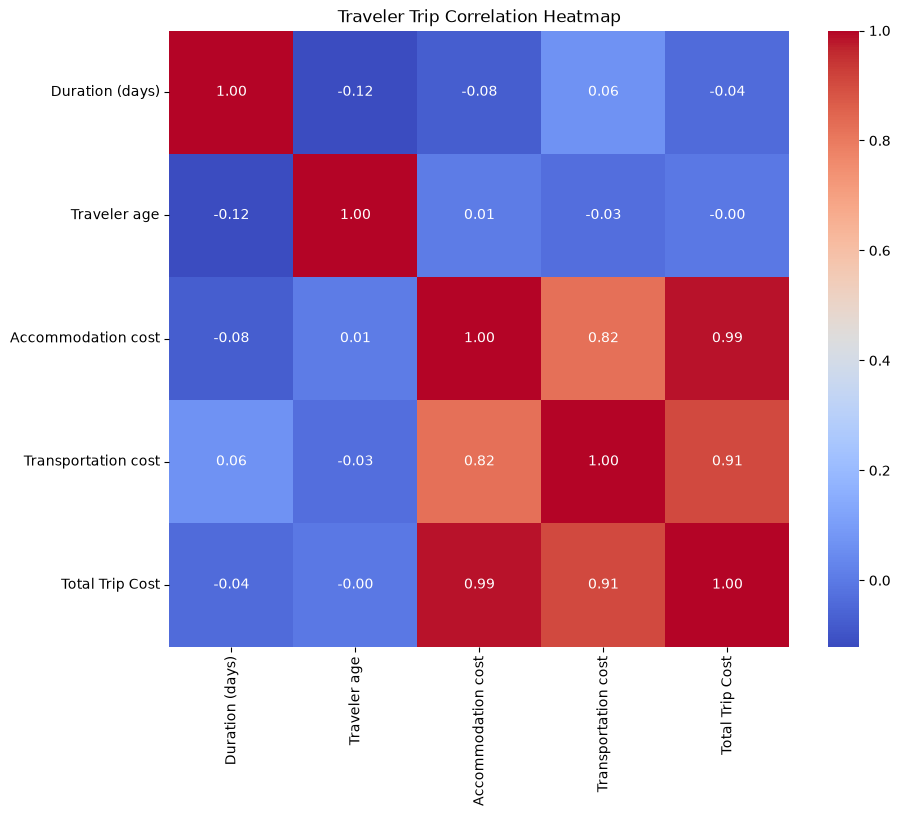

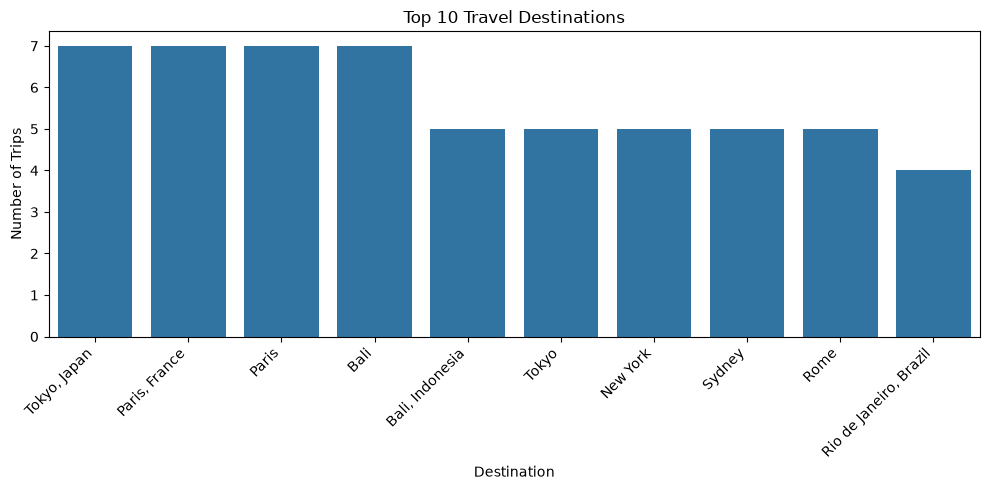

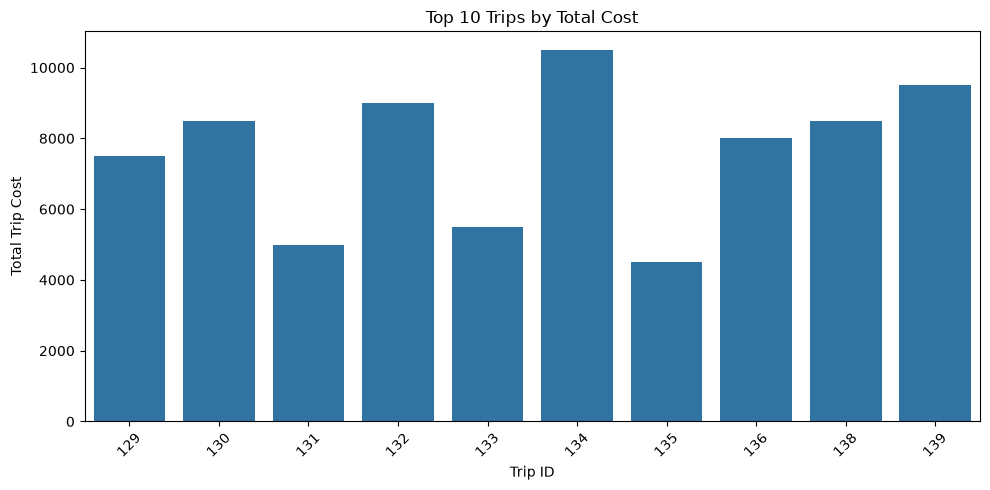

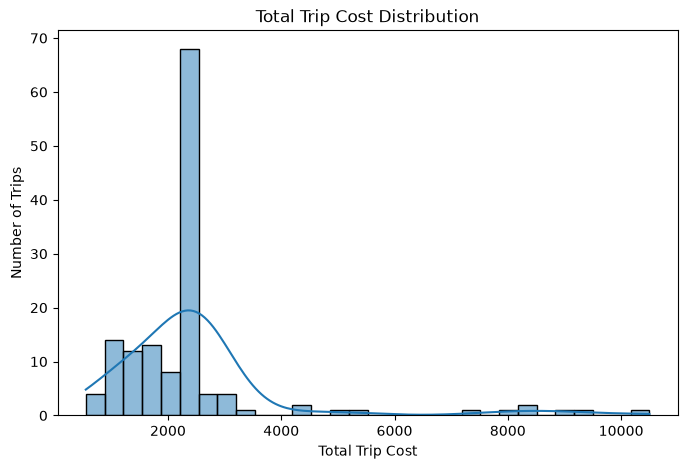

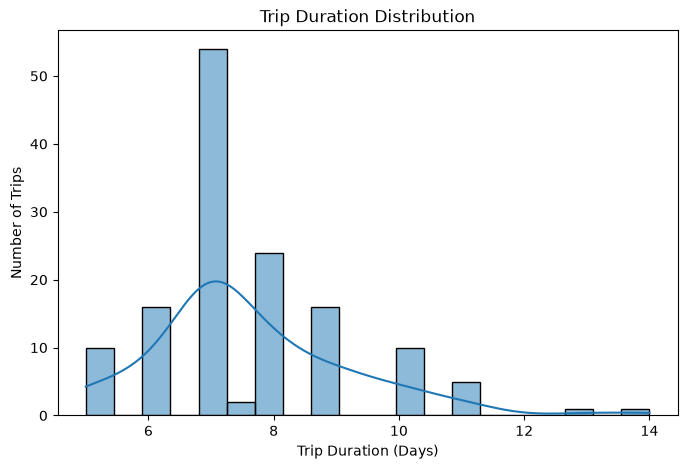

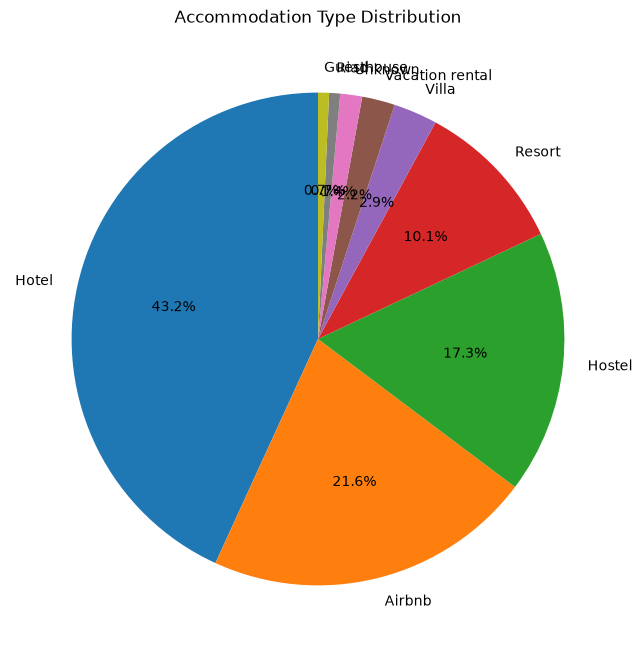

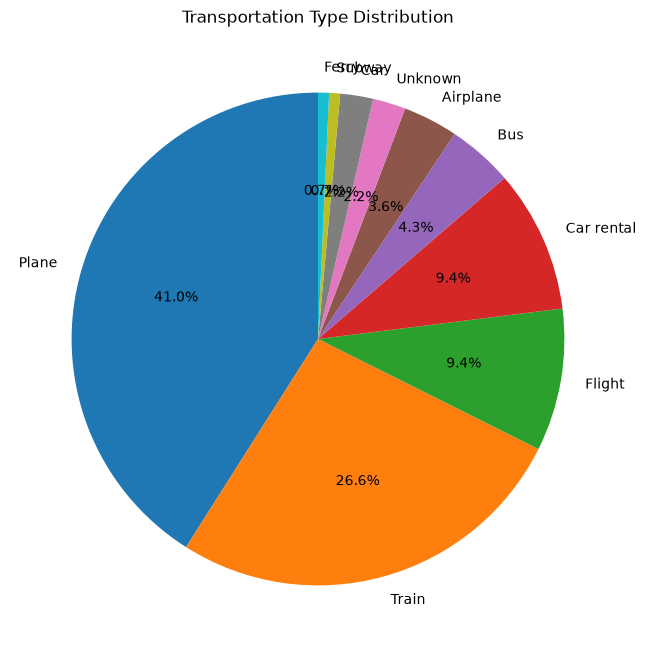

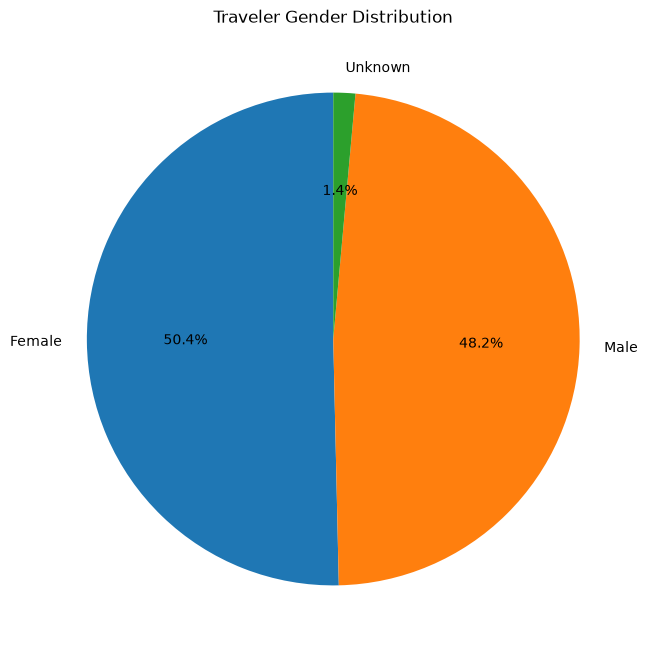

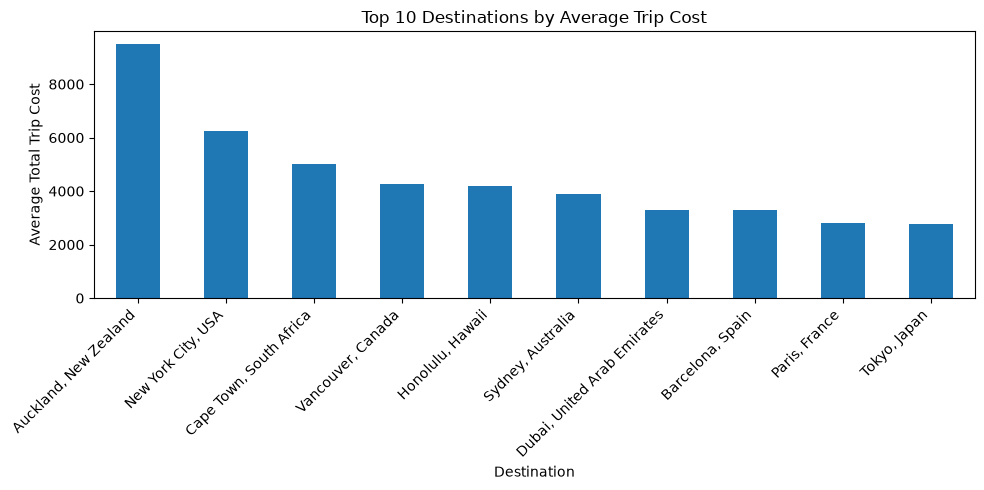

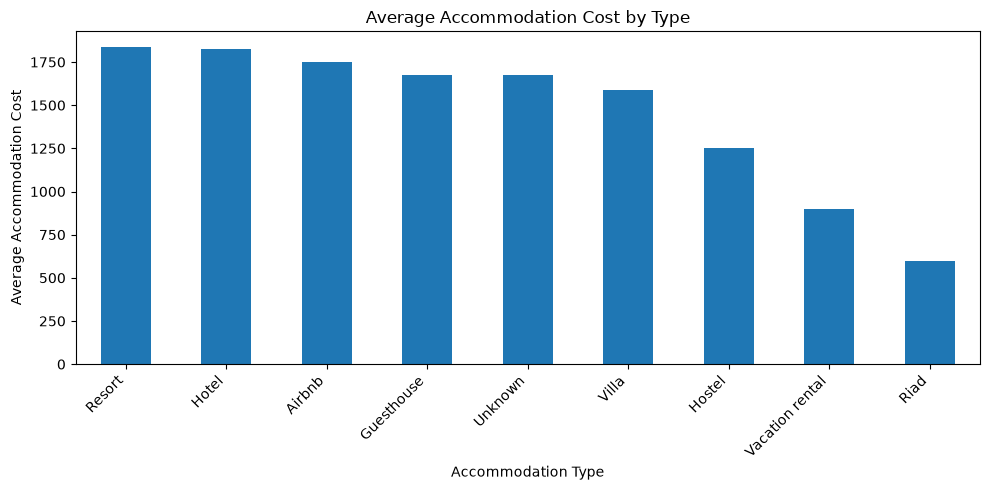

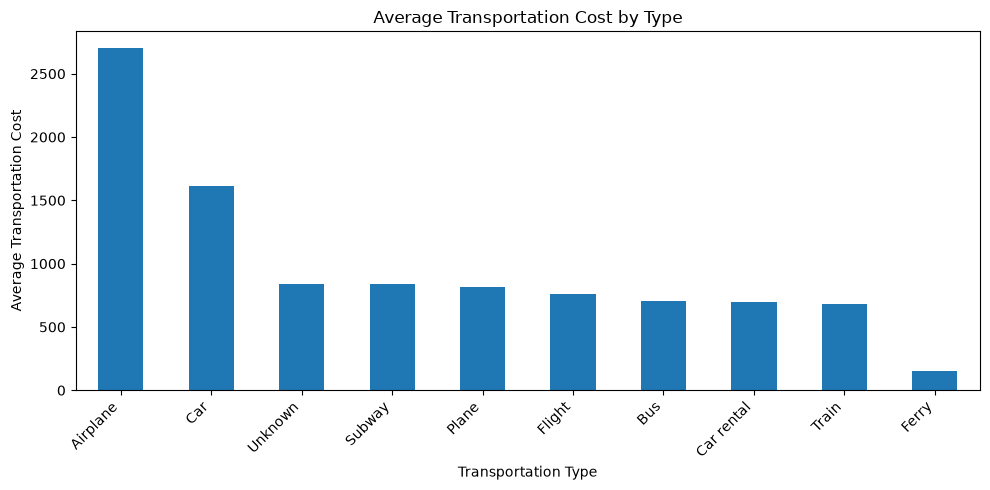

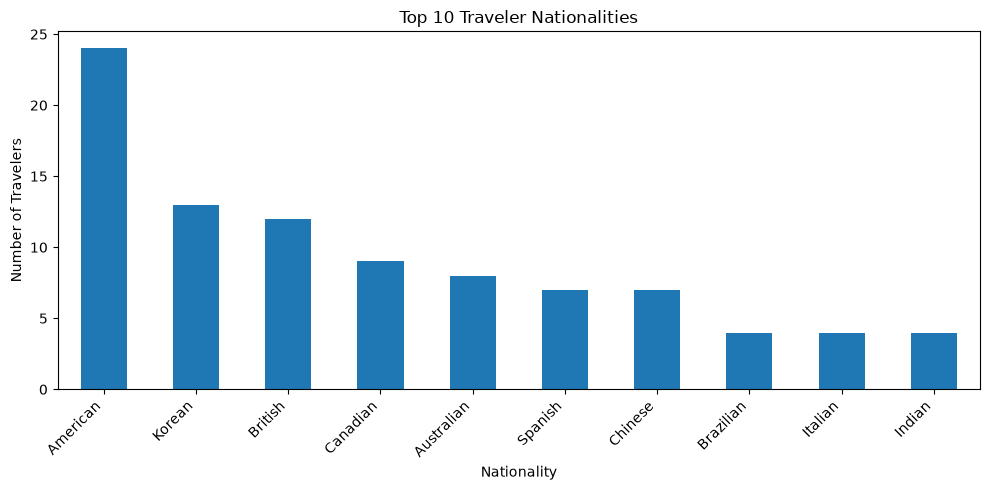

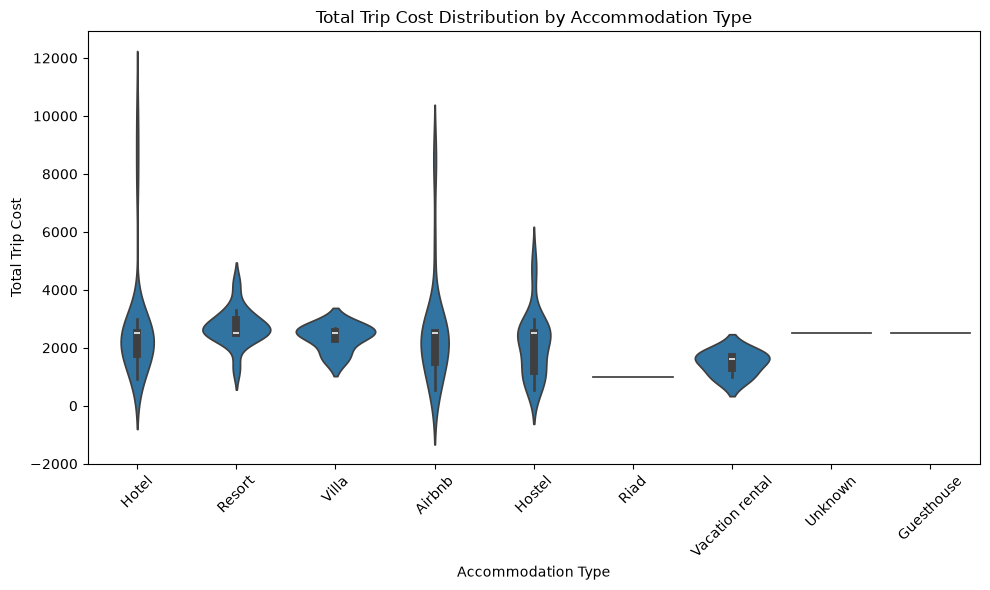

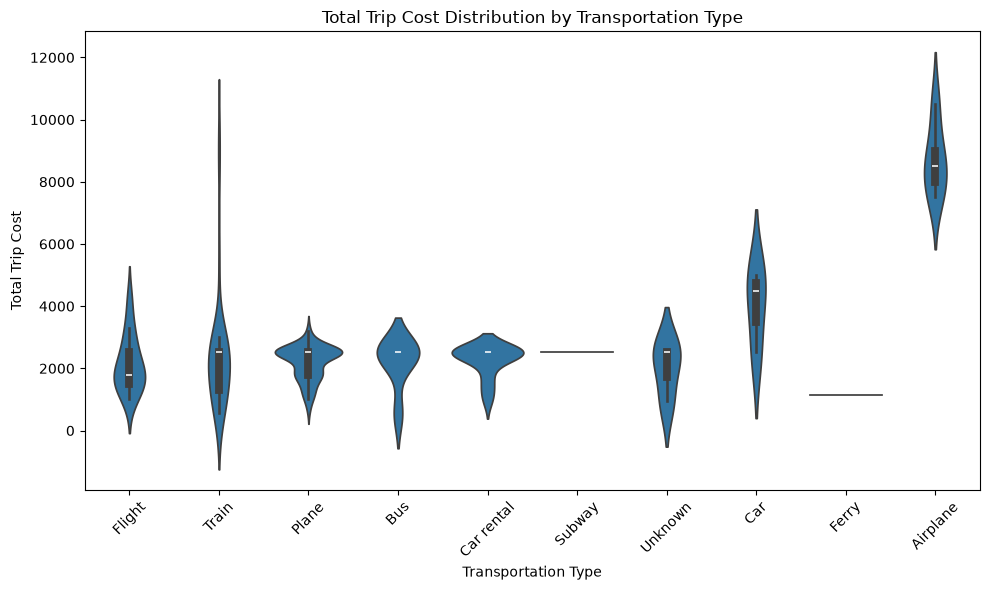

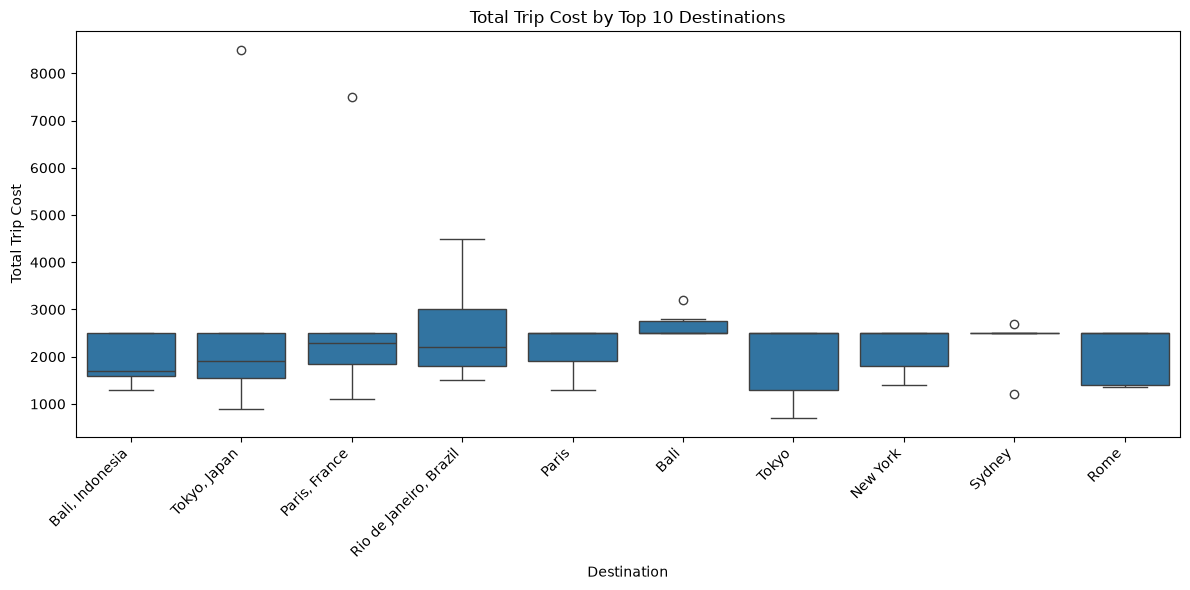

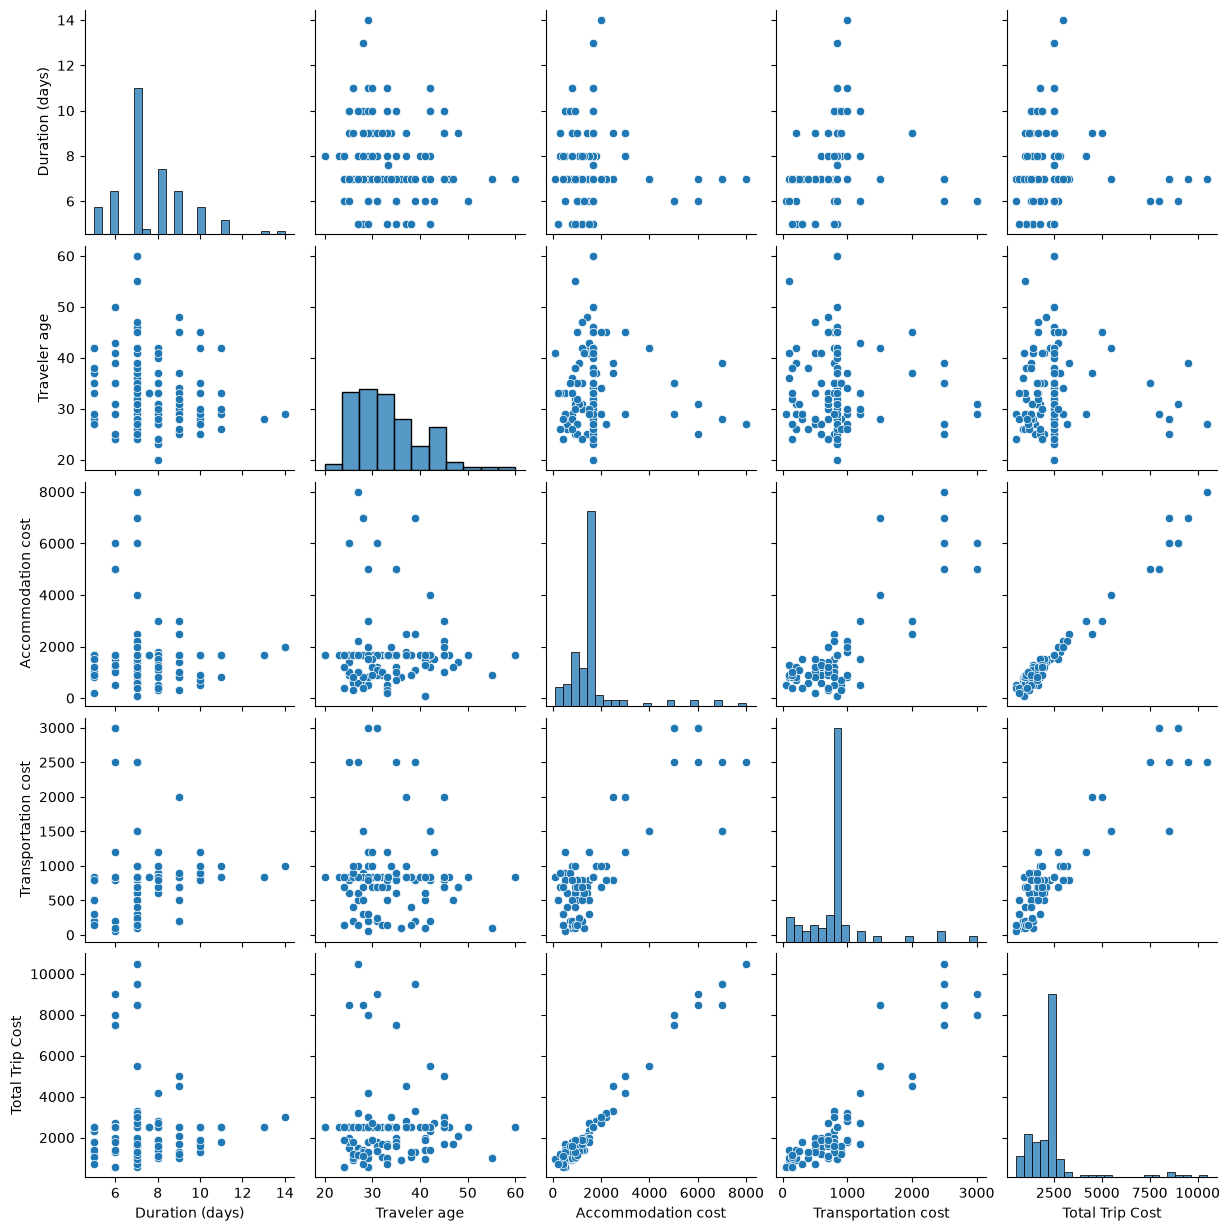

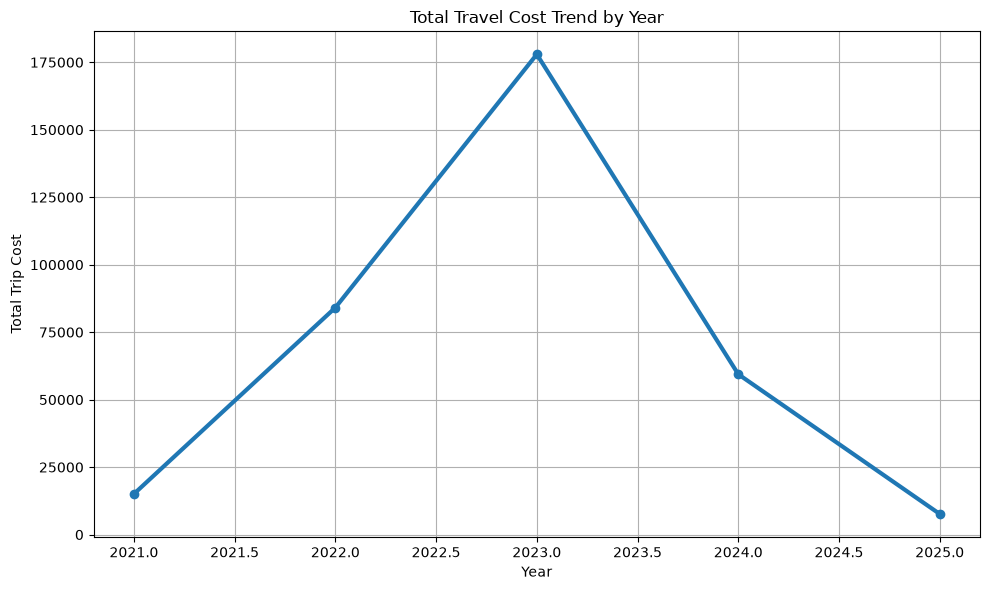

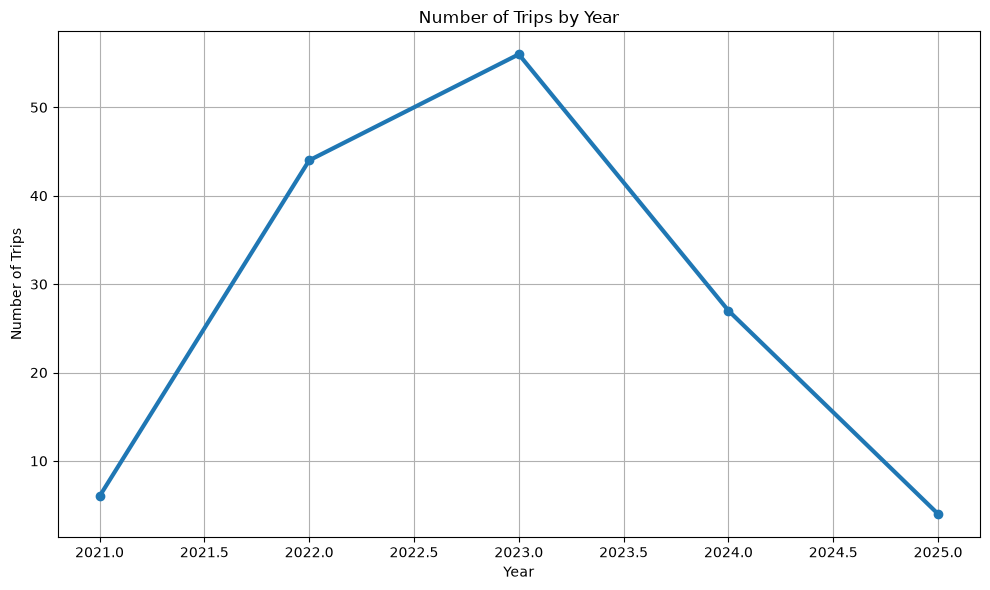

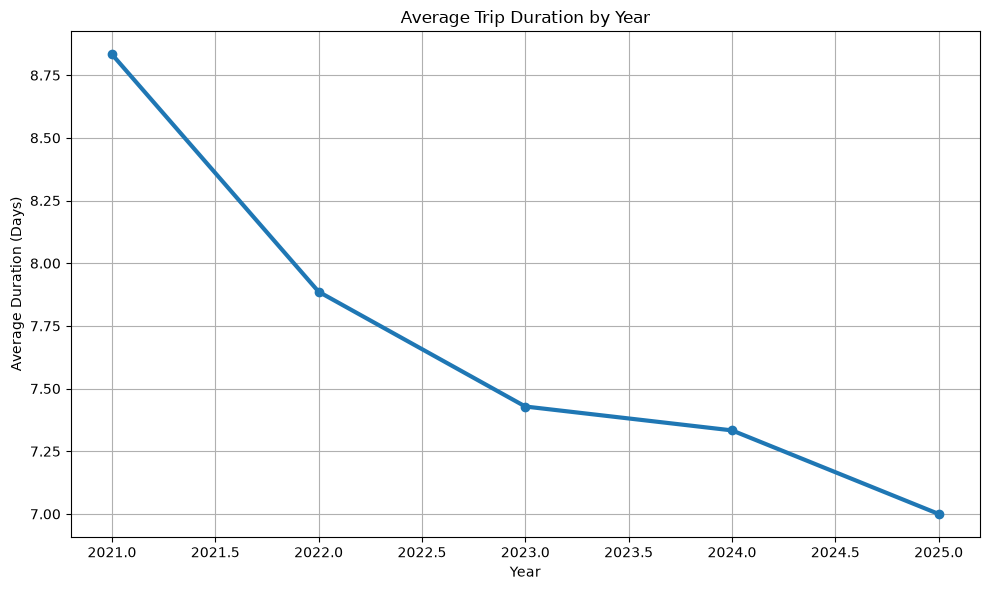



          TRAVELER TRIP ANALYSIS
                 COMPLETE

Dataset Rows : 139
Dataset Columns : 15

Numeric Columns:
['Trip ID', 'Duration (days)', 'Traveler age', 'Accommodation cost', 'Transportation cost', 'Total Trip Cost']

Categorical Columns:
['Destination', 'Start date', 'End date', 'Traveler name', 'Traveler gender', 'Traveler nationality', 'Accommodation type', 'Transportation type']

Total Trip Cost : 349218.4663536776

Most Visited Destination:
Destination
Tokyo, Japan    7
Name: count, dtype: int64

Most Common Accommodation:
Accommodation type
Hotel    60
Name: count, dtype: int64

Most Common Transportation:
Transportation type
Plane    57
Name: count, dtype: int64

Highest Average Trip Cost Destination:
Destination
Auckland, New Zealand    9500.0
Name: Total Trip Cost, dtype: float64

Analysis completed successfully!


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)



df = pd.read_csv("Travel details dataset.csv")

df.columns = df.columns.str.strip()

print("Dataset loaded successfully!")

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())



print("\nData Types:")

print(df.dtypes)


print("\nDescriptive Statistics:")

display(
    df.describe()
)



print("\nMissing Values:")

print(df.isnull().sum())



print("\nDuplicate Rows:")

print(df.duplicated().sum())




# Remove duplicate rows

df = df.drop_duplicates()


# Convert date columns

df["Start date"] = pd.to_datetime(
    df["Start date"],
    errors="coerce"
)

df["End date"] = pd.to_datetime(
    df["End date"],
    errors="coerce"
)



numeric_cols = [
    "Duration (days)",
    "Traveler age",
    "Accommodation cost",
    "Transportation cost"
]

for col in numeric_cols:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )



for col in numeric_cols:

    df[col] = df[col].fillna(
        df[col].mean()
    )



categorical_cols = [
    "Destination",
    "Traveler gender",
    "Traveler nationality",
    "Accommodation type",
    "Transportation type"
]



for col in categorical_cols:

    df[col] = df[col].fillna(
        "Unknown"
    )


print("\nMissing Values After Cleaning:")

print(df.isnull().sum())


df["Total Trip Cost"] = (
    df["Accommodation cost"]
    +
    df["Transportation cost"]
)

print("\nTotal Trip Cost calculated successfully.")

display(
    df[
        [
            "Trip ID",
            "Destination",
            "Total Trip Cost"
        ]
    ]
    .sort_values(
        by="Total Trip Cost",
        ascending=False
    )
    .head(10)
)


numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

print("\nNumeric Columns:")

print(numeric_cols)


categorical_cols = df.select_dtypes(
    exclude=np.number
).columns.tolist()

print("\nCategorical Columns:")

print(categorical_cols)



plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Duration (days)",
    y="Total Trip Cost"
)

plt.title(
    "Trip Duration vs Total Trip Cost"
)

plt.xlabel(
    "Trip Duration (Days)"
)

plt.ylabel(
    "Total Trip Cost"
)

plt.show()

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["Total Trip Cost"]
)

plt.title(
    "Total Trip Cost Outlier Detection"
)

plt.xlabel(
    "Total Trip Cost"
)

plt.show()



plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["Traveler age"]
)

plt.title(
    "Traveler Age Distribution"
)

plt.xlabel(
    "Traveler Age"
)

plt.show()


correlation_cols = [
    "Duration (days)",
    "Traveler age",
    "Accommodation cost",
    "Transportation cost",
    "Total Trip Cost"
]

corr = df[correlation_cols].corr()

print("\nCorrelation Matrix:")

display(corr)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Traveler Trip Correlation Heatmap"
)

plt.show()



plt.figure(figsize=(10, 5))

destination_order = (
    df["Destination"]
    .value_counts()
    .head(10)
    .index
)

sns.countplot(
    data=df[
        df["Destination"].isin(
            destination_order
        )
    ],
    x="Destination",
    order=destination_order
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.title(
    "Top 10 Travel Destinations"
)

plt.xlabel(
    "Destination"
)

plt.ylabel(
    "Number of Trips"
)

plt.tight_layout()

plt.show()

top_trips = (
    df[
        [
            "Trip ID",
            "Destination",
            "Total Trip Cost"
        ]
    ]
    .sort_values(
        "Total Trip Cost",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_trips,
    x="Trip ID",
    y="Total Trip Cost"
)

plt.xticks(rotation=45)

plt.title(
    "Top 10 Trips by Total Cost"
)

plt.xlabel(
    "Trip ID"
)

plt.ylabel(
    "Total Trip Cost"
)

plt.tight_layout()

plt.show()



plt.figure(figsize=(8, 5))

sns.histplot(
    df["Total Trip Cost"],
    bins=30,
    kde=True
)

plt.title(
    "Total Trip Cost Distribution"
)

plt.xlabel(
    "Total Trip Cost"
)

plt.ylabel(
    "Number of Trips"
)

plt.show()



plt.figure(figsize=(8, 5))

sns.histplot(
    df["Duration (days)"],
    bins=20,
    kde=True
)

plt.title(
    "Trip Duration Distribution"
)

plt.xlabel(
    "Trip Duration (Days)"
)

plt.ylabel(
    "Number of Trips"
)

plt.show()



accommodation = (
    df["Accommodation type"]
    .value_counts()
)

plt.figure(figsize=(8, 8))

plt.pie(
    accommodation,
    labels=accommodation.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Accommodation Type Distribution"
)

plt.show()



transportation = (
    df["Transportation type"]
    .value_counts()
)

plt.figure(figsize=(8, 8))

plt.pie(
    transportation,
    labels=transportation.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Transportation Type Distribution"
)

plt.show()



gender = (
    df["Traveler gender"]
    .value_counts()
)

plt.figure(figsize=(8, 8))

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Traveler Gender Distribution"
)

plt.show()



destination_cost = (
    df.groupby("Destination")[
        "Total Trip Cost"
    ]
    .mean()
    .sort_values(
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10, 5))

destination_cost.plot(
    kind="bar"
)

plt.title(
    "Top 10 Destinations by Average Trip Cost"
)

plt.xlabel(
    "Destination"
)

plt.ylabel(
    "Average Total Trip Cost"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()



accommodation_cost = (
    df.groupby("Accommodation type")[
        "Accommodation cost"
    ]
    .mean()
    .sort_values(
        ascending=False
    )
)

plt.figure(figsize=(10, 5))

accommodation_cost.plot(
    kind="bar"
)

plt.title(
    "Average Accommodation Cost by Type"
)

plt.xlabel(
    "Accommodation Type"
)

plt.ylabel(
    "Average Accommodation Cost"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

transportation_cost = (
    df.groupby("Transportation type")[
        "Transportation cost"
    ]
    .mean()
    .sort_values(
        ascending=False
    )
)

plt.figure(figsize=(10, 5))

transportation_cost.plot(
    kind="bar"
)

plt.title(
    "Average Transportation Cost by Type"
)

plt.xlabel(
    "Transportation Type"
)

plt.ylabel(
    "Average Transportation Cost"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


top_nationalities = (
    df["Traveler nationality"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 5))

top_nationalities.plot(
    kind="bar"
)

plt.title(
    "Top 10 Traveler Nationalities"
)

plt.xlabel(
    "Nationality"
)

plt.ylabel(
    "Number of Travelers"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="Accommodation type",
    y="Total Trip Cost"
)

plt.xticks(rotation=45)

plt.title(
    "Total Trip Cost Distribution by Accommodation Type"
)

plt.xlabel(
    "Accommodation Type"
)

plt.ylabel(
    "Total Trip Cost"
)

plt.tight_layout()

plt.show()



plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="Transportation type",
    y="Total Trip Cost"
)

plt.xticks(rotation=45)

plt.title(
    "Total Trip Cost Distribution by Transportation Type"
)

plt.xlabel(
    "Transportation Type"
)

plt.ylabel(
    "Total Trip Cost"
)

plt.tight_layout()

plt.show()



top_destinations = (
    df["Destination"]
    .value_counts()
    .head(10)
    .index
)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[
        df["Destination"].isin(
            top_destinations
        )
    ],
    x="Destination",
    y="Total Trip Cost"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.title(
    "Total Trip Cost by Top 10 Destinations"
)

plt.xlabel(
    "Destination"
)

plt.ylabel(
    "Total Trip Cost"
)

plt.tight_layout()

plt.show()


pair_columns = [
    "Duration (days)",
    "Traveler age",
    "Accommodation cost",
    "Transportation cost",
    "Total Trip Cost"
]

sns.pairplot(
    df[pair_columns].dropna()
)

plt.show()



df["Start Year"] = (
    df["Start date"]
    .dt.year
)

year_cost = (
    df.groupby("Start Year")[
        "Total Trip Cost"
    ]
    .sum()
)

plt.figure(figsize=(10, 6))

plt.plot(
    year_cost.index,
    year_cost.values,
    marker="o",
    linewidth=3
)

plt.title(
    "Total Travel Cost Trend by Year"
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Total Trip Cost"
)

plt.grid(True)

plt.tight_layout()

plt.show()



year_trips = (
    df.groupby("Start Year")
    .size()
)

plt.figure(figsize=(10, 6))

plt.plot(
    year_trips.index,
    year_trips.values,
    marker="o",
    linewidth=3
)

plt.title(
    "Number of Trips by Year"
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Number of Trips"
)

plt.grid(True)

plt.tight_layout()

plt.show()



year_duration = (
    df.groupby("Start Year")[
        "Duration (days)"
    ]
    .mean()
)

plt.figure(figsize=(10, 6))

plt.plot(
    year_duration.index,
    year_duration.values,
    marker="o",
    linewidth=3
)

plt.title(
    "Average Trip Duration by Year"
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Average Duration (Days)"
)

plt.grid(True)

plt.tight_layout()

plt.show()



print("\n")
print("==============================================")
print("          TRAVELER TRIP ANALYSIS")
print("                 COMPLETE")
print("==============================================")

print(
    "\nDataset Rows :",
    df.shape[0]
)

print(
    "Dataset Columns :",
    df.shape[1]
)

print(
    "\nNumeric Columns:"
)

print(numeric_cols)

print(
    "\nCategorical Columns:"
)

print(categorical_cols)

print(
    "\nTotal Trip Cost :",
    df["Total Trip Cost"].sum()
)

print(
    "\nMost Visited Destination:"
)

print(
    df["Destination"]
    .value_counts()
    .head(1)
)

print(
    "\nMost Common Accommodation:"
)

print(
    df["Accommodation type"]
    .value_counts()
    .head(1)
)

print(
    "\nMost Common Transportation:"
)

print(
    df["Transportation type"]
    .value_counts()
    .head(1)
)

print(
    "\nHighest Average Trip Cost Destination:"
)

print(
    df.groupby("Destination")["Total Trip Cost"]
    .mean()
    .sort_values(ascending=False)
    .head(1)
)

print(
    "\nAnalysis completed successfully!"
)